# Guía Práctica: EDA con Python
Curso de Fundamentos de Ciencia de Datos

Dataset: Tips

## Objetivos de la clase
- Realizar un EDA sistemático.
- Calcular medidas de resumen (centralidad, dispersión, forma).
- Visualizar distribuciones y relaciones.
- Incorporar variables categóricas.
- Comparar grupos con prueba t de Student.


# Carga de módulos y dataset

In [ ]:
# Importar módulos necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Cargar dataset tips (viene en Seaborn, pero podemos cargarlo directamente)
# Si no tienes seaborn, usa esta URL:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

# Ver primeras filas
print("Primeras 5 filas:")
print(tips.head())

# Info general
print("\nInformación del dataset:")
print(tips.info())

Primeras 5 filas:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


Pregunta:

    ¿Qué tipos de variables tenemos? ¿Cuántos registros?

# Medidas de resumen

In [ ]:
# Medidas de tendencia central y dispersión para variables numéricas
num_vars = ['total_bill', 'tip', 'size']

print("=== Medidas de resumen ===")
for var in num_vars:
    print(f"\n--- {var} ---")
    print(f"Media: {tips[var].mean():.2f}")
    print(f"Mediana: {tips[var].median():.2f}")
    print(f"Moda: {tips[var].mode().values[0]}")
    print(f"Desv. estándar: {tips[var].std():.2f}")
    print(f"Mín: {tips[var].min()}, Máx: {tips[var].max()}")
    print(f"Rango intercuartílico (IQR): {tips[var].quantile(0.75) - tips[var].quantile(0.25):.2f}")

# Resumen completo con describe()
print("\n=== Describe (numéricas) ===")
print(tips[num_vars].describe())

# Para categóricas: frecuencias
cat_vars = ['sex', 'smoker', 'day', 'time']
for var in cat_vars:
    print(f"\n--- {var} ---")
    print(tips[var].value_counts())

=== Medidas de resumen ===

--- total_bill ---
Media: 19.79
Mediana: 17.80
Moda: 13.42
Desv. estándar: 8.90
Mín: 3.07, Máx: 50.81
Rango intercuartílico (IQR): 10.78

--- tip ---
Media: 3.00
Mediana: 2.90
Moda: 2.0
Desv. estándar: 1.38
Mín: 1.0, Máx: 10.0
Rango intercuartílico (IQR): 1.56

--- size ---
Media: 2.57
Mediana: 2.00
Moda: 2
Desv. estándar: 0.95
Mín: 1, Máx: 6
Rango intercuartílico (IQR): 1.00

=== Describe (numéricas) ===
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000

--- sex ---
sex
Male      157
Female     87
Name: count, dtype: int64

--- smoker ---
smoker
No     151
Yes     93
Name: count, dtype: int64

--- day ---
day
Sat     87
Sun     76
Thur

# Visualizaciones básicas

## Histogramoas y boxplots

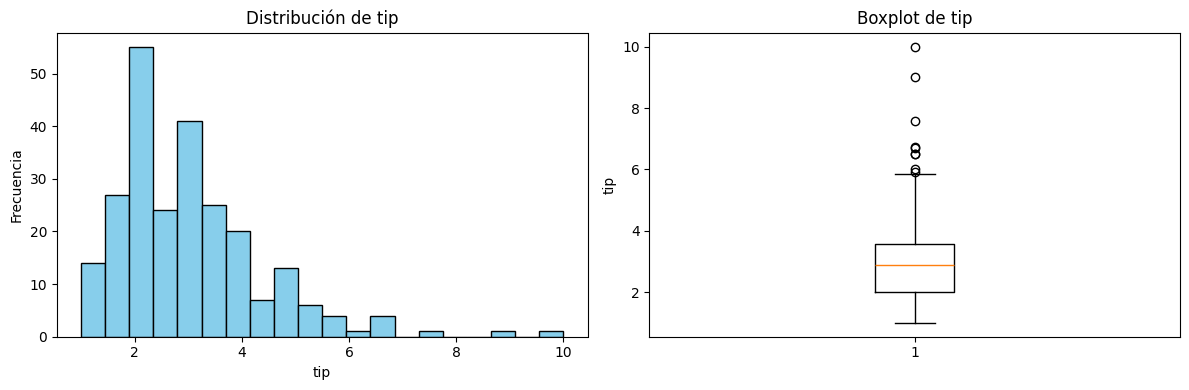

In [ ]:
variable = "tip"
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Histograma
axes[0].hist(tips[variable], bins=20, edgecolor='black', color='skyblue')
axes[0].set_title(f'Distribución de {variable}')
axes[0].set_xlabel(f'{variable}')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(tips[variable], vert=True)
axes[1].set_title(f'Boxplot de {variable}')
axes[1].set_ylabel(f'{variable}')

plt.tight_layout()
plt.show()

In [ ]:
# Ejemplo de gráficos interactivos
from ipywidgets import interact

In [ ]:
def plot(variable):
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))
  # Histograma
  axes[0].hist(tips[variable], bins=20, edgecolor='black', color='skyblue')
  axes[0].set_title(f'Distribución de {variable}')
  axes[0].set_xlabel(f'{variable}')
  axes[0].set_ylabel('Frecuencia')

  # Boxplot
  axes[1].boxplot(tips[variable], vert=True)
  axes[1].set_title(f'Boxplot de {variable}')
  axes[1].set_ylabel(f'{variable}')

  plt.tight_layout()
  plt.show()

interact(plot, variable=['total_bill', 'tip', 'size'])

interactive(children=(Dropdown(description='variable', options=('total_bill', 'tip', 'size'), value='total_bil…

<function __main__.plot(variable)>

## Gráfico de dispersión: total_bill vs tip

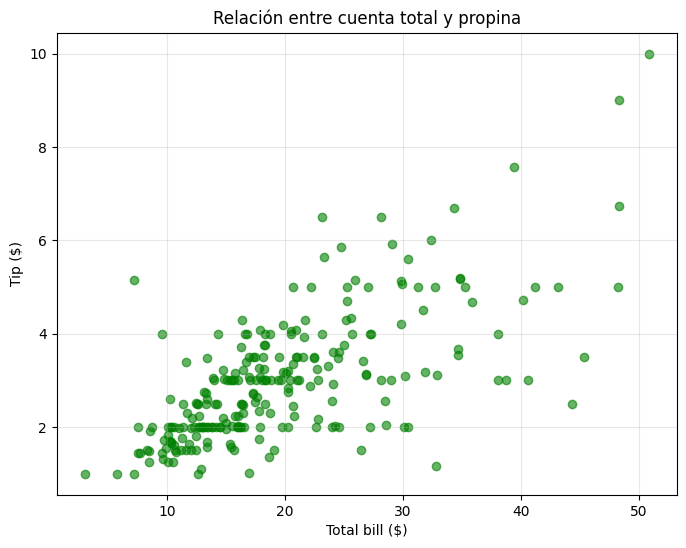

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6, color='green')
plt.xlabel('Total bill ($)')
plt.ylabel('Tip ($)')
plt.title('Relación entre cuenta total y propina')
plt.grid(True, alpha=0.3)
plt.show()

## Incluir categorías: colorear por smoker


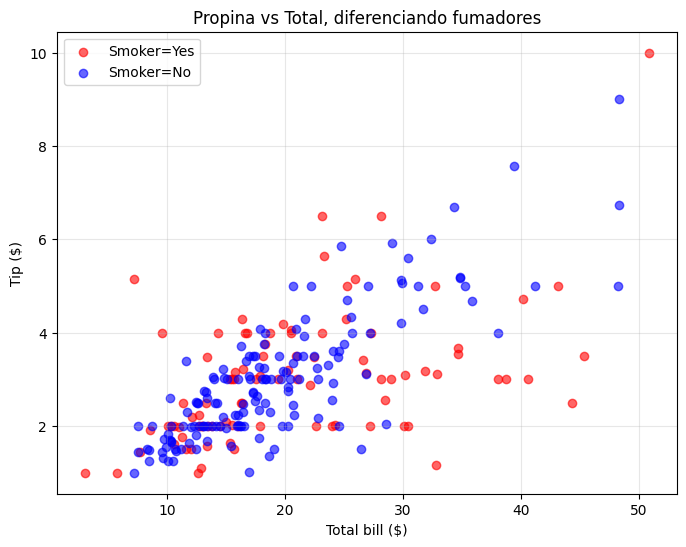

In [ ]:
colors = {'Yes': 'red', 'No': 'blue'}
plt.figure(figsize=(8, 6))
for smoker, color in colors.items():
    subset = tips[tips['smoker'] == smoker]
    plt.scatter(subset['total_bill'], subset['tip'],
                label=f'Smoker={smoker}', alpha=0.6, color=color)
plt.xlabel('Total bill ($)')
plt.ylabel('Tip ($)')
plt.title('Propina vs Total, diferenciando fumadores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Análisis con variables categóricas

## Diagrama de barras: propina promedio por día

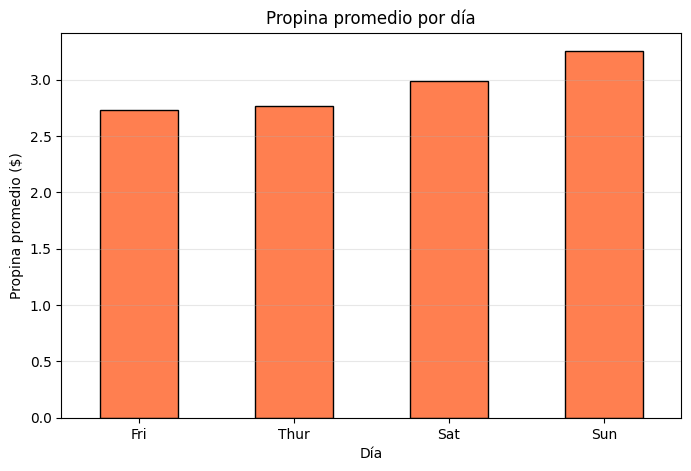

In [ ]:
tip_por_dia = tips.groupby('day')['tip'].mean().sort_values()

plt.figure(figsize=(8, 5))
tip_por_dia.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Propina promedio por día')
plt.xlabel('Día')
plt.ylabel('Propina promedio ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Boxplots agrupados: propina por género y hora


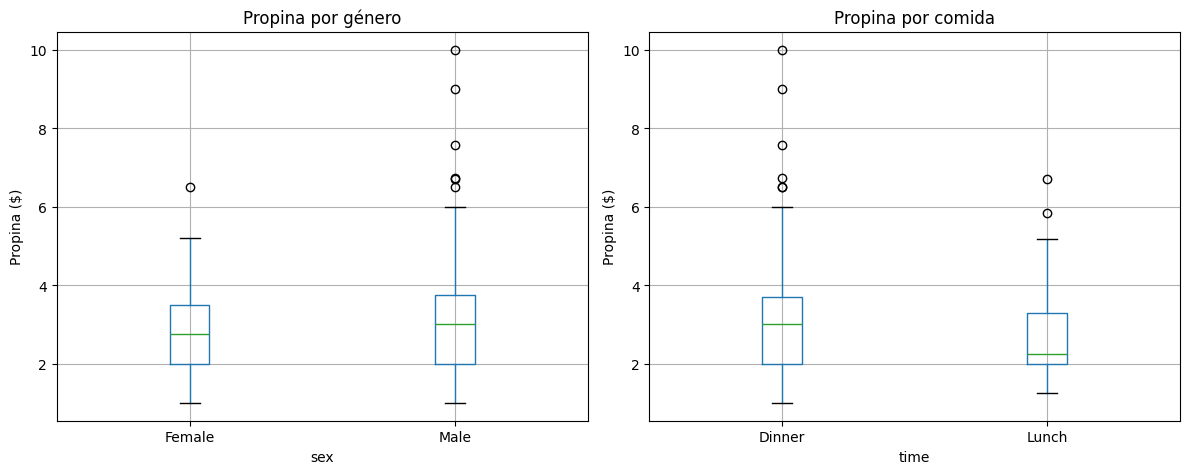

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Por género
tips.boxplot(column='tip', by='sex', ax=axes[0])
axes[0].set_title('Propina por género')
axes[0].set_ylabel('Propina ($)')

# Por hora (almuerzo/cena)
tips.boxplot(column='tip', by='time', ax=axes[1])
axes[1].set_title('Propina por comida')
axes[1].set_ylabel('Propina ($)')

plt.suptitle('')
plt.tight_layout()
plt.show()

# Análisis Bivariante

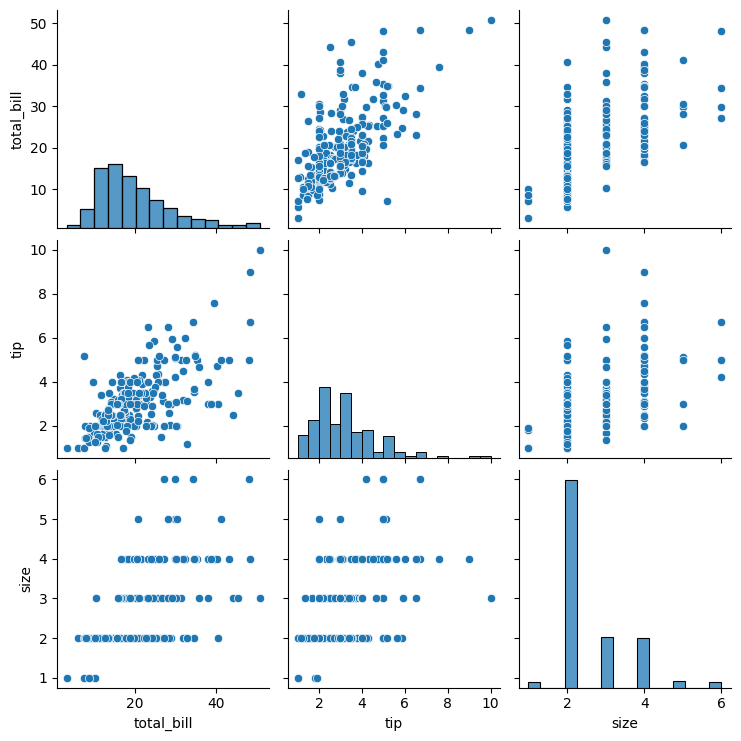

In [ ]:
sns.pairplot(tips)


# Análisis Multivariable

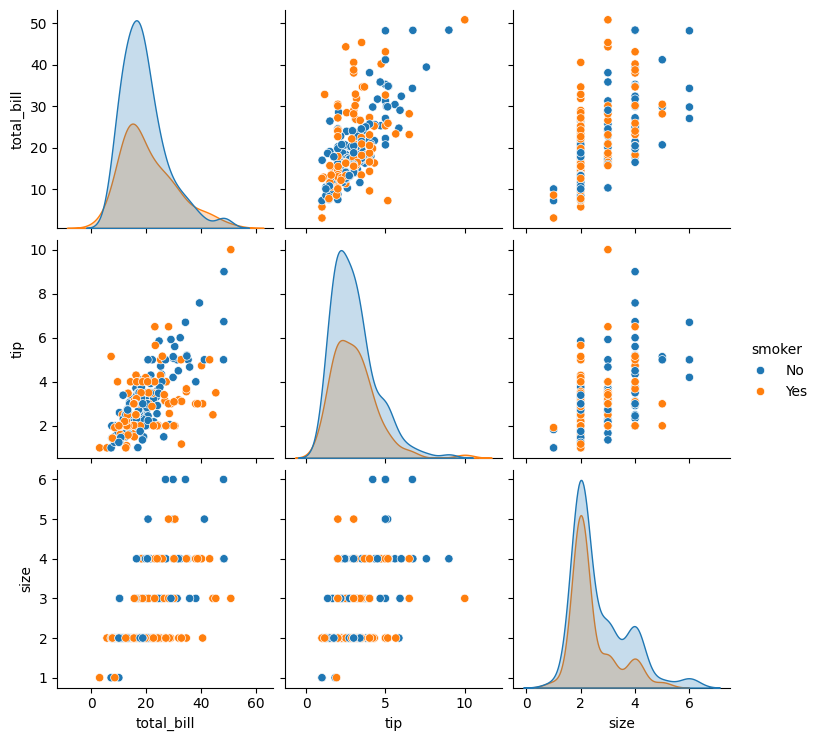

In [ ]:
sns.pairplot(tips, hue="smoker")


# Análisis de correlaciones

<Axes: >

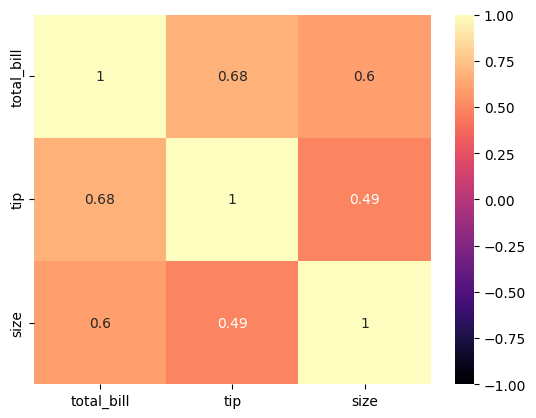

In [ ]:
sns.heatmap(tips[num_vars].corr(), vmin=-1, vmax=1, cmap='magma', annot=True)


# Coordenadas Paralelas

In [ ]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler


In [ ]:
# Necesitamos normalizar los datos de manera explicita
scaler = MinMaxScaler()
def coord_par(variable):
  tips_normalizado = tips[['total_bill', 'tip', 'size']].copy()
  tips_normalizado[['total_bill', 'tip', 'size']] = scaler.fit_transform(tips_normalizado)

  # Añadir categorías
  tips_normalizado[variable] = tips[variable]

  # Gráfico por día
  plt.figure(figsize=(12, 6))
  parallel_coordinates(tips_normalizado, variable,
                      colormap=plt.cm.Set3,
                      alpha=0.6,
                      linewidth=0.8)

  plt.title(f'Coordenadas Paralelas - Tips / Por: {variable}', fontsize=14, fontweight='bold')
  plt.xlabel('Variables', fontsize=12)
  plt.ylabel('Valores Normalizados', fontsize=12)
  plt.legend(title='Día', bbox_to_anchor=(1.05, 1))
  plt.grid(True, alpha=0.3)
  plt.xticks(rotation=0)
  plt.tight_layout()
  plt.show()

interact(coord_par, variable=['sex', 'smoker', 'day','time'])

interactive(children=(Dropdown(description='variable', options=('sex', 'smoker', 'day', 'time'), value='sex'),…

<function __main__.coord_par(variable)>

# Prueba t de Student

In [ ]:
# Separar grupos
tips_si = tips[tips['smoker'] == 'Yes']['tip']
tips_no = tips[tips['smoker'] == 'No']['tip']

# Prueba t para dos muestras independientes
t_stat, p_value = stats.ttest_ind(tips_si, tips_no)

print("=== Comparación de propinas: fumadores vs no fumadores ===")
print(f"Media fumadores: {tips_si.mean():.2f}")
print(f"Media no fumadores: {tips_no.mean():.2f}")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Rechazamos H0: hay diferencia significativa en las propinas.")
else:
    print("No rechazamos H0: no hay evidencia suficiente de diferencia.")

# Verificar supuestos
# Homogeneidad de varianzas -homocedasticidad (prueba de Levene)
# H0: Las varianzas de todos los grupos son iguales.
# H1: Las varianzas no son todas iguales (al menos un grupo difiere)
# p >= alfa No hay rechazo de H0. Se asumen varianzas iguales

_, p_levene = stats.levene(tips_si, tips_no)
print(f"\nPrueba de Levene para igualdad de varianzas  p > 0.05 : p = {p_levene:.4f}")

=== Comparación de propinas: fumadores vs no fumadores ===
Media fumadores: 3.01
Media no fumadores: 2.99
Estadístico t: 0.0922
Valor p: 0.9266
No rechazamos H0: no hay evidencia suficiente de diferencia.

Prueba de Levene para igualdad de varianzas: p = 0.8862


# Trabajo Práctico

Este trabajo no requiere entrega, es un ejercicio para fijar algunos conceptos vistos en la clase. Los resultados pueden ser discutidos en clases posteriores.



## Datos

El dataset Wine proviene del UCI Machine Learning Repository y fue donado por Riccardo Leardi (Universidad de Génova). Contiene los resultados de un análisis químico de vinos cultivados en la misma región de Italia, pero derivados de tres cultivares diferentes (tres tipos de vino). El análisis determinó las cantidades de 13 componentes químicos para cada uno de los 178 vinos analizados.

Cita: Aeberhard, S., & Forina, M. (1992). Wine [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5PC7J


## Hipótesis para verificar mediante EDA

A continuación se presentan 5 hipótesis que deberán verificar utilizando técnicas de Análisis Exploratorio de Datos (EDA), incluyendo medidas de resumen, visualizaciones univariadas y multivariadas, matrices de correlación y pruebas estadísticas (como prueba t) en el caso que corresponda.

### Hipótesis 1: Los tres tipos de vino (cultivares) se diferencian significativamente en su contenido de alcohol.

**Pregunta de investigación**: ¿El nivel de alcohol permite distinguir entre los tres cultivares?



### Hipótesis 2: Existe una correlación fuerte entre los flavonoides y los fenoles totales.

**Pregunta de investigación**: ¿Los vinos con alto contenido de flavonoides también tienden a tener altos niveles de fenoles totales?

### Hipótesis 3: La intensidad del color y la tonalidad (hue) varían sistemáticamente entre los tipos de vino.

**Pregunta de investigación**: ¿Los cultivares presentan perfiles distintos en términos de color y tonalidad?

### Hipótesis 4: El contenido de prolina y magnesio están asociados positivamente.

**Pregunta de investigación**: ¿Los vinos con mayor contenido de magnesio también presentan mayores niveles de prolina?

### Hipótesis 5: El tipo de vino (clase) puede predecirse razonablemente usando solo 3 o 4 variables químicas.

**Pregunta de investigación**: ¿Existe un subconjunto reducido de variables que permita diferenciar claramente los tres cultivares?